In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/processed/survey_v1.1.json"

with open(DATA_PATH) as f:
    data = json.load(f)

N = len(data)
print(f"Loaded {N} records, {len(data[0])} fields each.")

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Colour palette (one per section)
C_MEAS  = "#4C72B0"   # blue  – measures
C_BUILD = "#55A868"   # green – building
C_SOCIO = "#C44E52"   # red   – sociodemographics
C_TRIG  = "#DD8452"   # orange – triggers & subsidies

def pct_of(values, total=None):
    """Return list of percentages."""
    t = total or sum(values)
    return [v / t * 100 for v in values]

def get_field(field, cast=str):
    """Return non-null values of a field, cast to type."""
    return [cast(r[field]) for r in data if r.get(field) is not None]

Loaded 1651 records, 143 fields each.


---
## 2 · Building Characteristics

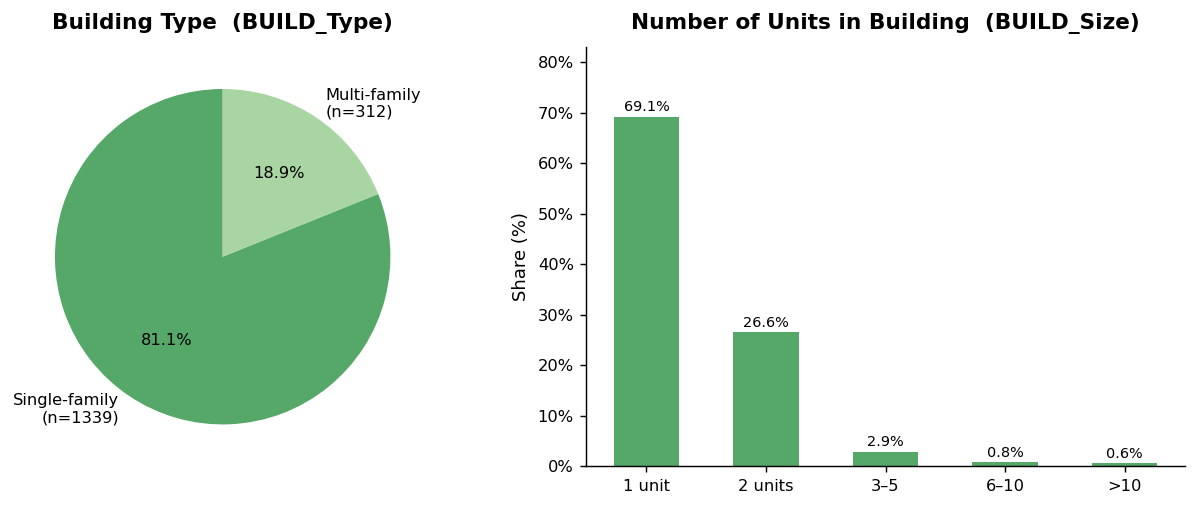

In [2]:
# ── 2a: Building type & size (2-panel) ────────────────────────────────────────
type_map  = {"1": "Single-family", "2": "Multi-family"}
size_map  = {"1": "1 unit", "2": "2 units", "3": "3–5", "4": "6–10", "5": ">10"}

type_raw  = Counter(get_field("BUILD_Type"))
size_raw  = Counter(get_field("BUILD_Size"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie — building type
t_keys   = sorted(type_raw, key=int)
t_vals   = [type_raw[k] for k in t_keys]
t_labels = [f"{type_map[k]}\n(n={type_raw[k]})" for k in t_keys]
axes[0].pie(t_vals, labels=t_labels, autopct="%1.1f%%",
            colors=[C_BUILD, "#a8d5a2"], startangle=90,
            textprops={"fontsize": 9})
axes[0].set_title("Building Type  (BUILD_Type)", pad=10)

# Bar — building size
s_keys   = sorted(size_raw, key=int)
s_vals   = [size_raw[k] for k in s_keys]
s_labels = [size_map[k] for k in s_keys]
s_pcts   = pct_of(s_vals)
bars = axes[1].bar(s_labels, s_pcts, color=C_BUILD, width=0.55)
axes[1].set_title("Number of Units in Building  (BUILD_Size)", pad=10)
axes[1].set_ylabel("Share (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, max(s_pcts) * 1.2)
for bar, pct, cnt in zip(bars, s_pcts, s_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

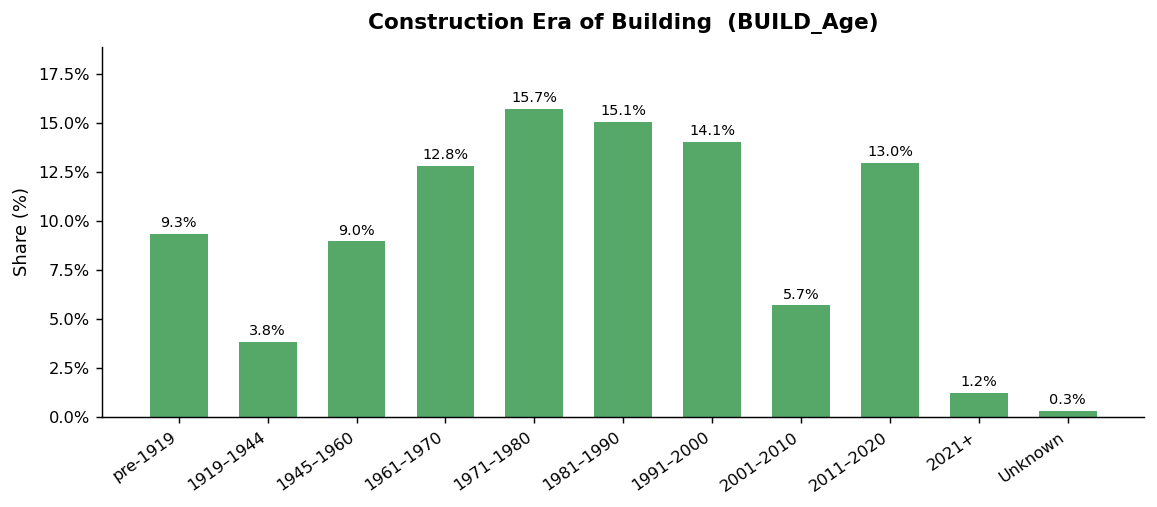

In [3]:
# ── 2b: Building construction era ─────────────────────────────────────────────
age_map = {
    "1":  "pre-1919",
    "2":  "1919–1944",
    "3":  "1945–1960",
    "4":  "1961–1970",
    "5":  "1971–1980",
    "6":  "1981–1990",
    "7":  "1991–2000",
    "8":  "2001–2010",
    "9":  "2011–2020",
    "10": "2021+",
    "11": "Unknown",
}

age_raw = Counter(get_field("BUILD_Age"))
a_keys  = sorted(age_raw, key=int)
a_vals  = [age_raw[k] for k in a_keys]
a_labels= [age_map[k] for k in a_keys]
a_pcts  = pct_of(a_vals)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(a_labels, a_pcts, color=C_BUILD, width=0.65)
ax.set_title("Construction Era of Building  (BUILD_Age)", pad=10)
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(a_pcts) * 1.2)
plt.xticks(rotation=35, ha="right")
for bar, pct, cnt in zip(bars, a_pcts, a_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

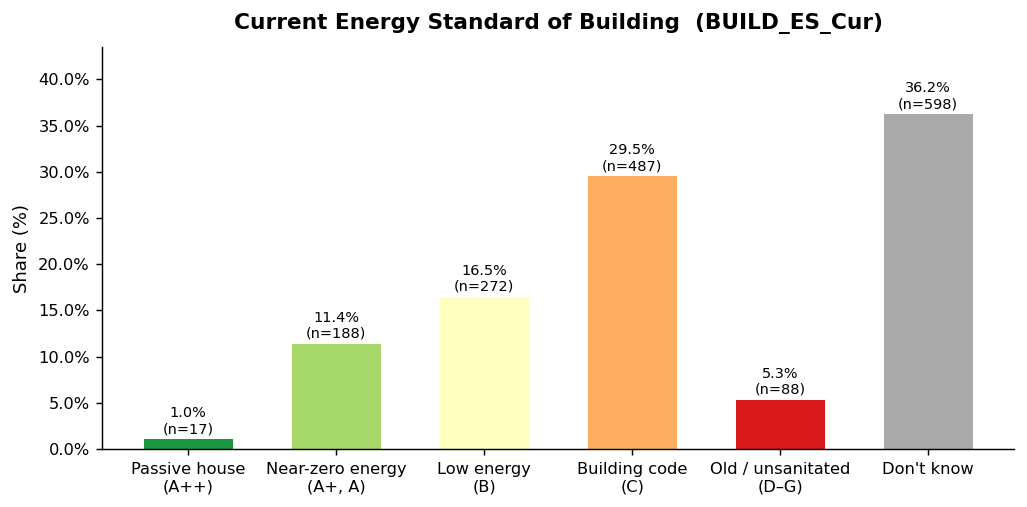

In [4]:
# ── 2c: Current energy standard ───────────────────────────────────────────────
es_map = {
    "1": "Passive house\n(A++)",
    "2": "Near-zero energy\n(A+, A)",
    "3": "Low energy\n(B)",
    "4": "Building code\n(C)",
    "5": "Old / unsanitated\n(D–G)",
    "6": "Don't know",
}

es_raw  = Counter(get_field("BUILD_ES_Cur"))
es_keys = sorted(es_raw, key=int)
es_vals = [es_raw[k] for k in es_keys]
es_lbl  = [es_map[k] for k in es_keys]
es_pcts = pct_of(es_vals)

# Colour gradient: green (efficient) → red (inefficient) → grey (unknown)
es_colors = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c", "#aaaaaa"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(es_lbl, es_pcts, color=es_colors[:len(es_keys)], width=0.6)
ax.set_title("Current Energy Standard of Building  (BUILD_ES_Cur)", pad=10)
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(es_pcts) * 1.2)
for bar, pct, cnt in zip(bars, es_pcts, es_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{pct:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

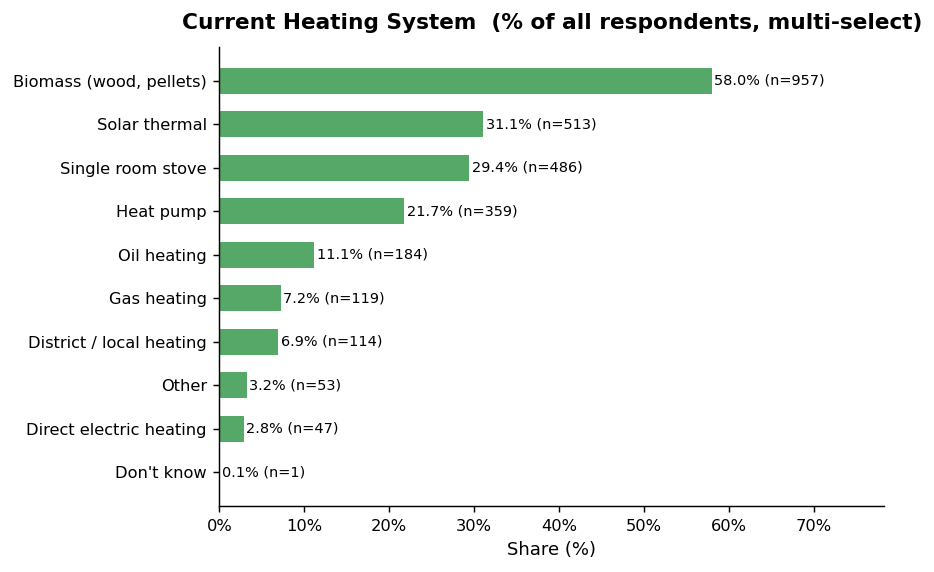

In [5]:
# ── 2d: Current heating systems (multi-select) ────────────────────────────────
hs_fields = [f"BUILD_HS{i}" for i in range(1, 11)]
hs_labels = [
    "District / local heating",
    "Oil heating",
    "Gas heating",
    "Biomass (wood, pellets)",
    "Single room stove",
    "Direct electric heating",
    "Heat pump",
    "Solar thermal",
    "Other",
    "Don't know",
]

hs_yes  = [sum(1 for r in data if str(r.get(f, '0')) == '1') for f in hs_fields]
hs_pcts = pct_of(hs_yes, N)

# Sort descending, drop zeros
order   = sorted(range(len(hs_pcts)), key=lambda i: hs_pcts[i], reverse=True)
order   = [i for i in order if hs_yes[i] > 0]
s_lbl   = [hs_labels[i] for i in order]
s_pcts  = [hs_pcts[i]   for i in order]
s_cnts  = [hs_yes[i]    for i in order]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(s_lbl[::-1], s_pcts[::-1], color=C_BUILD, height=0.6)
ax.set_title("Current Heating System  (% of all respondents, multi-select)", pad=10)
ax.set_xlabel("Share (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, pct, cnt in zip(bars, s_pcts[::-1], s_cnts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={cnt})", va="center", fontsize=8)
ax.set_xlim(0, max(s_pcts) * 1.35)
plt.tight_layout()
plt.show()

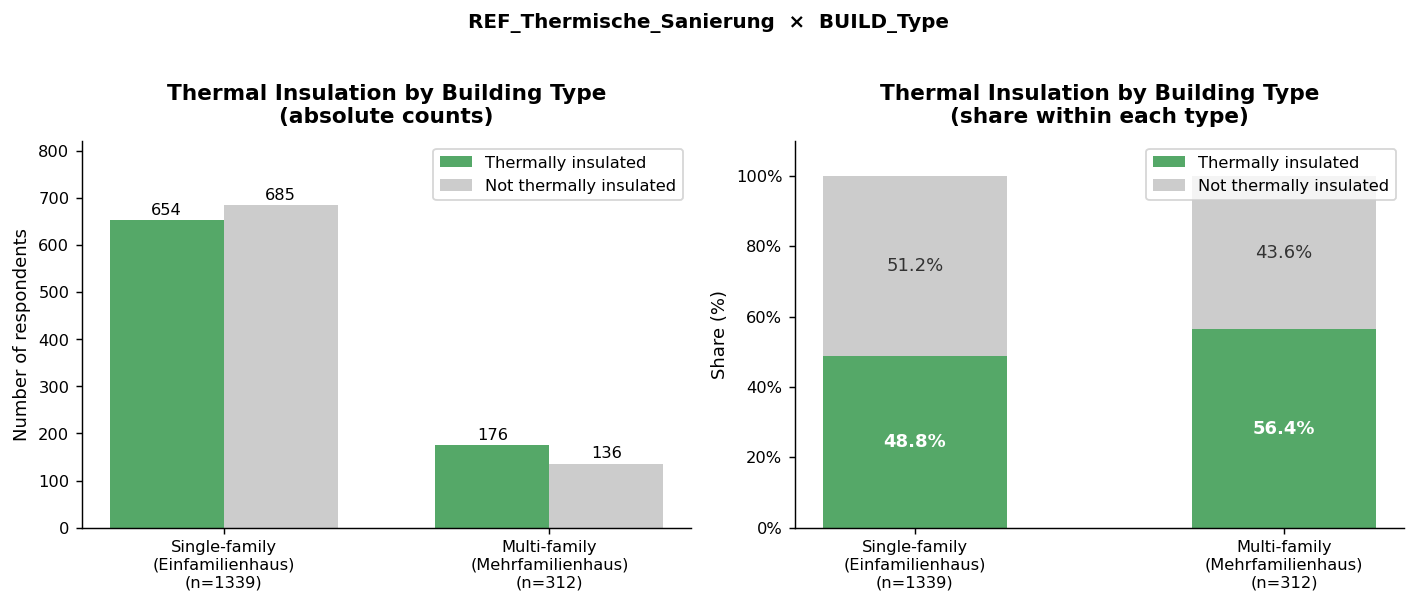

In [6]:
# ── 2e: Thermal insulation by building type ───────────────────────────────────
# REF_Thermische_Sanierung = 1 if any of REF_1/2/3/4 was done (facade, roof, basement, windows)
build_type_map = {"1": "Single-family\n(Einfamilienhaus)", "2": "Multi-family\n(Mehrfamilienhaus)"}
bt_keys = ["1", "2"]

bt_yes, bt_no, bt_ns = [], [], []
for bt in bt_keys:
    members = [r for r in data if str(r.get("BUILD_Type", "")) == bt]
    n       = len(members)
    yes     = sum(1 for r in members if str(r.get("REF_Thermische_Sanierung", "")) == "1")
    bt_yes.append(yes)
    bt_no.append(n - yes)
    bt_ns.append(n)

bt_yes_pct = [y / n * 100 for y, n in zip(bt_yes, bt_ns)]
bt_no_pct  = [o / n * 100 for o, n in zip(bt_no,  bt_ns)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: grouped bar (absolute counts)
x     = np.arange(len(bt_keys))
w     = 0.35
xlbls = [f"{build_type_map[k]}\n(n={bt_ns[i]})" for i, k in enumerate(bt_keys)]

bars_yes = axes[0].bar(x - w/2, bt_yes, w, label="Thermally insulated",     color=C_BUILD)
bars_no  = axes[0].bar(x + w/2, bt_no,  w, label="Not thermally insulated", color="#cccccc")
axes[0].set_title("Thermal Insulation by Building Type\n(absolute counts)", pad=10)
axes[0].set_ylabel("Number of respondents")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlbls, fontsize=9)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max(bt_yes + bt_no) * 1.2)
for bar, cnt in zip(list(bars_yes) + list(bars_no), bt_yes + bt_no):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(cnt), ha="center", va="bottom", fontsize=9)

# Right: 100% stacked bar (proportions)
bars_yes2 = axes[1].bar(x, bt_yes_pct,                   color=C_BUILD,   width=0.5, label="Thermally insulated")
bars_no2  = axes[1].bar(x, bt_no_pct, bottom=bt_yes_pct, color="#cccccc", width=0.5, label="Not thermally insulated")
axes[1].set_title("Thermal Insulation by Building Type\n(share within each type)", pad=10)
axes[1].set_ylabel("Share (%)")
axes[1].set_ylim(0, 110)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlbls, fontsize=9)
axes[1].legend(fontsize=9, loc="upper right")
for i, (yp, np_) in enumerate(zip(bt_yes_pct, bt_no_pct)):
    axes[1].text(i, yp / 2,         f"{yp:.1f}%", ha="center", va="center", fontsize=10, color="white", fontweight="bold")
    axes[1].text(i, yp + np_ / 2,   f"{np_:.1f}%", ha="center", va="center", fontsize=10, color="#333")

plt.suptitle("REF_Thermische_Sanierung  ×  BUILD_Type", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()